### Ejercicio 1: Crear el Grafo Básico
Objetivo: Leer el archivo CSV y crear un grafo básico con los nodos y aristas.

In [9]:
import matplotlib.pyplot as plt

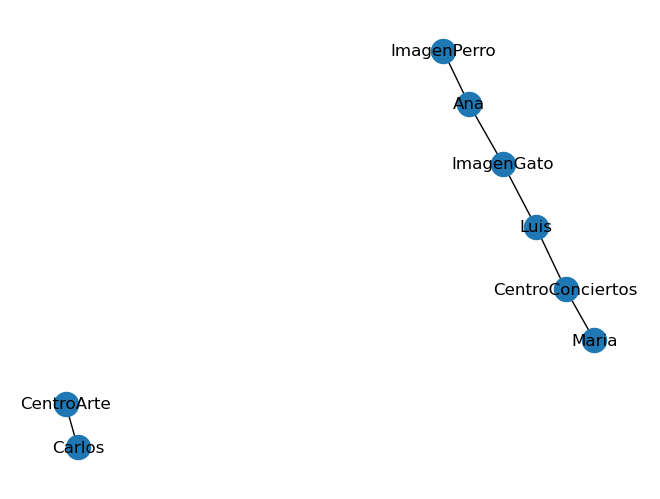

In [2]:
import networkx as nx
import pandas as pd

# Leer el archivo CSV
df = pd.read_csv('tuit.csv', delimiter=';')

# Crear el grafo
G = nx.Graph()

# Añadir nodos y aristas
for index, row in df.iterrows():
    nodo1 = row['NODO1']
    nodo2 = row['NODO2']
    relacion = row['RELACION']
    
    G.add_node(nodo1)
    G.add_node(nodo2)
    G.add_edge(nodo1, nodo2, relacion=relacion)

# Dibujar el grafo
nx.draw(G, with_labels=True)

### Ejercicio 2: Calcular Grados de los Nodos
Objetivo: Calcular y mostrar el grado de cada nodo en el grafo.

In [3]:
# Calcular el grado de cada nodo
grados = dict(G.degree())
print("Grados de los nodos:", grados)

Grados de los nodos: {'Ana': 2, 'ImagenPerro': 1, 'Luis': 2, 'ImagenGato': 2, 'Maria': 1, 'CentroConciertos': 2, 'Carlos': 1, 'CentroArte': 1}


### Ejercicio 3: Encontrar Nodos con Mayor Centralidad
Objetivo: Calcular la centralidad de los nodos y encontrar los nodos con mayor centralidad.

In [4]:
# Calcular la centralidad de los nodos
centralidad = nx.degree_centrality(G)
print("Centralidad de los nodos:", centralidad)

# Encontrar los nodos con mayor centralidad
nodos_mayor_centralidad = sorted(centralidad, key=centralidad.get, reverse=True)[:5]
print("Nodos con mayor centralidad:", nodos_mayor_centralidad)

Centralidad de los nodos: {'Ana': 0.2857142857142857, 'ImagenPerro': 0.14285714285714285, 'Luis': 0.2857142857142857, 'ImagenGato': 0.2857142857142857, 'Maria': 0.14285714285714285, 'CentroConciertos': 0.2857142857142857, 'Carlos': 0.14285714285714285, 'CentroArte': 0.14285714285714285}
Nodos con mayor centralidad: ['Ana', 'Luis', 'ImagenGato', 'CentroConciertos', 'ImagenPerro']


In [ ]:
Ejercicio 4: Visualización de Subgrafos
Objetivo: Crear y visualizar subgrafos basados en tipos de nodos (usuarios, imágenes, centros de eventos).

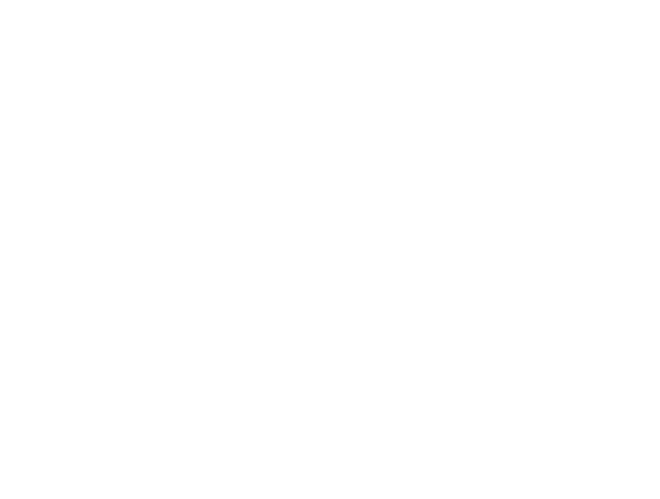

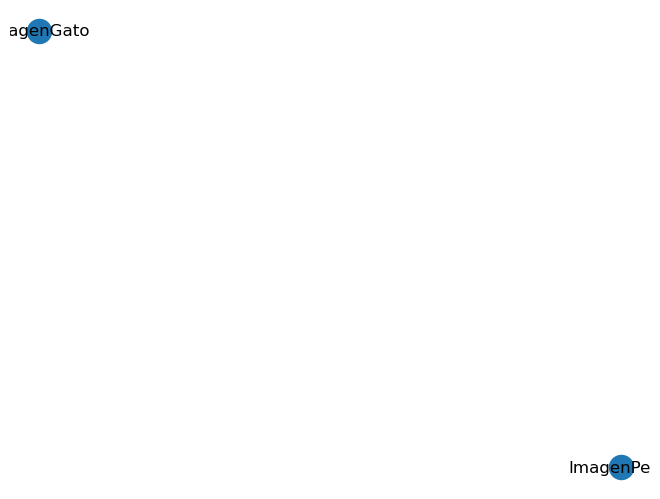

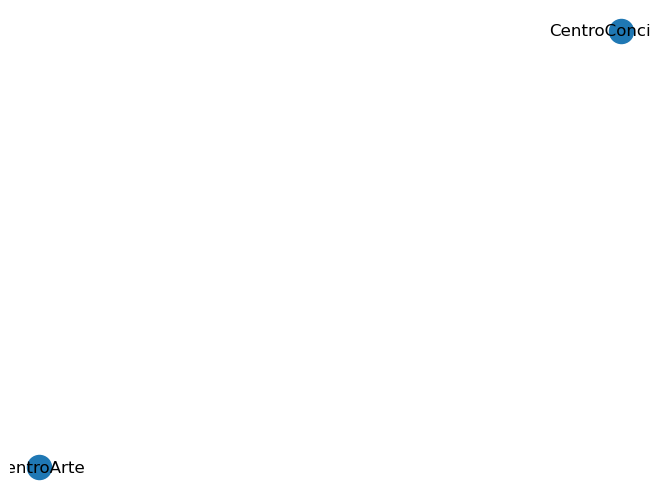

In [11]:
# Crear subgrafos
usuarios = [n for n in G.nodes() if 'Usuario' in n]
imagenes = [n for n in G.nodes() if 'Imagen' in n]
centros_eventos = [n for n in G.nodes() if 'Centro' in n]

subgrafo_usuarios = G.subgraph(usuarios)
subgrafo_imagenes = G.subgraph(imagenes)
subgrafo_centros_eventos = G.subgraph(centros_eventos)

# Dibujar subgrafos
nx.draw(subgrafo_usuarios, with_labels=True)
plt.show()

nx.draw(subgrafo_imagenes, with_labels=True)
plt.show()

nx.draw(subgrafo_centros_eventos, with_labels=True)
plt.show()

### Ejercicio 5: Análisis de Componentes Conexas
Objetivo: Identificar y analizar las componentes conexas del grafo.

In [13]:
# Identificar componentes conexas
componentes_conexas = list(nx.connected_components(G))
print("Componentes conexas:", componentes_conexas)

# Analizar componentes conexas
for i, componente in enumerate(componentes_conexas):
    subgrafo = G.subgraph(componente)
    print(f"Componente {i+1}:")
    print('-------------------------')
    print("Nodos:", subgrafo.nodes())
    print('-------------------------')
    print("Aristas:", subgrafo.edges())

Componentes conexas: [{'Luis', 'Ana', 'CentroConciertos', 'ImagenGato', 'ImagenPerro', 'Maria'}, {'CentroArte', 'Carlos'}]
Componente 1:
-------------------------
Nodos: ['Ana', 'ImagenPerro', 'Luis', 'ImagenGato', 'Maria', 'CentroConciertos']
-------------------------
Aristas: [('Ana', 'ImagenPerro'), ('Ana', 'ImagenGato'), ('Luis', 'ImagenGato'), ('Luis', 'CentroConciertos'), ('Maria', 'CentroConciertos')]
Componente 2:
-------------------------
Nodos: ['CentroArte', 'Carlos']
-------------------------
Aristas: [('CentroArte', 'Carlos')]


### Ejercicio 6: Busquedas
Objetivo: Conocer el algoritmo de búsqueda en anchura

In [14]:
import networkx as nx

def BFS(G,v0):
    encontrados={v0}
    procesados =set()
    en_proceso =[v0]
    while en_proceso:
        v=en_proceso[0]
        print(v) #Aquí decidimos que hacer al comenzar a procesar un vértice
        for w in G.neighbors(v):
            if (w not in procesados) and (w not in encontrados):
                encontrados.add(w)
                en_proceso.append(w)
        en_proceso.remove(v)
        procesados.add(v)

In [15]:
BFS(G,'Ana')

Ana
ImagenPerro
ImagenGato
Luis
CentroConciertos
Maria


## Ejercicio 6: Búsqueda de Caminos en el Grafo
Objetivo: Encontrar el camino más corto entre dos nodos específicos utilizando el algoritmo de búsqueda de caminos.

### Ejercicio 6.1: Búsqueda de Caminos
Objetivo: Encontrar el camino más corto entre dos nodos específicos.

In [17]:
# Definir los nodos de inicio y fin
nodo_inicio = "Ana"
nodo_fin = "CentroConciertos"

# Encontrar el camino más corto
camino_mas_corto = nx.shortest_path(G, source=nodo_inicio, target=nodo_fin)
print(f"Camino más corto entre {nodo_inicio} y {nodo_fin}: {camino_mas_corto}")

Camino más corto entre Ana y CentroConciertos: ['Ana', 'ImagenGato', 'Luis', 'CentroConciertos']


### Ejercicio 6.2: Búsqueda de Todos los Caminos
Objetivo: Encontrar todos los caminos posibles entre dos nodos específicos.

In [18]:
# Definir los nodos de inicio y fin
nodo_inicio = "Ana"
nodo_fin = "CentroConciertos"

# Encontrar todos los caminos posibles
todos_caminos = list(nx.all_simple_paths(G, source=nodo_inicio, target=nodo_fin))
print(f"Todos los caminos entre {nodo_inicio} y {nodo_fin}:")
for camino in todos_caminos:
    print(camino)

Todos los caminos entre Ana y CentroConciertos:
['Ana', 'ImagenGato', 'Luis', 'CentroConciertos']


### Ejercicio 6.3: Búsqueda de Caminos con Restricciones
Objetivo: Encontrar el camino más corto entre dos nodos específicos con una restricción en el tipo de relación.

In [21]:
# Definir los nodos de inicio y fin
nodo_inicio = "Ana"
nodo_fin = "ImagenGato"

restriccion='like'
# Crear un subgrafo con la restricción de relación
subgrafo_like = nx.Graph((n1, n2, e) for n1, n2, e in G.edges(data=True) if e['relacion'] == restriccion)

# Encontrar el camino más corto en el subgrafo con la restricción
camino_mas_corto_like = nx.shortest_path(subgrafo_like, source=nodo_inicio, target=nodo_fin)
print(f"Camino más corto entre {nodo_inicio} y {nodo_fin} con relación 'like': {camino_mas_corto_like}")

Camino más corto entre Ana y ImagenGato con relación 'like': ['Ana', 'ImagenGato']


## Enunciado: Extracción de Indicadores de Grafos para Modelos de Machine Learning
Objetivo:
Extraer indicadores clave de un grafo que representen relaciones en redes sociales y utilizar estos indicadores para entrenar un modelo de machine learning.

### Indicadores a Extraer:
* Grado de los Nodos: Número de conexiones de cada nodo.
* Centralidad de Grado: Importancia de los nodos basada en su grado.
* Centralidad de Intermediación: Frecuencia con la que un nodo actúa como puente en el grafo.
* Centralidad de Cercanía: Qué tan cerca está un nodo de todos los demás nodos en el grafo.
* Componentes Conexas: Número de componentes conexas en el grafo.
* Densidad del Grafo: Proporción de aristas presentes en comparación con el número máximo posible de aristas.
* Coeficiente de Agrupamiento: Medida de la tendencia de los nodos a formar cliques.

In [22]:
# Grado de los Nodos
grados = dict(G.degree())

# Centralidad de Grado
centralidad_grado = nx.degree_centrality(G)

# Centralidad de Intermediación
centralidad_intermediacion = nx.betweenness_centrality(G)

# Centralidad de Cercanía
centralidad_cercania = nx.closeness_centrality(G)

# Componentes Conexas
componentes_conexas = nx.number_connected_components(G)

# Densidad del Grafo
densidad = nx.density(G)

# Coeficiente de Agrupamiento
coeficiente_agrupamiento = nx.clustering(G)

In [24]:
# Crear el DataFrame
indicadores_df = pd.DataFrame({
    'Nodo': list(G.nodes()),
    'Grado': [grados[nodo] for nodo in G.nodes()],
    'Centralidad_Grado': [centralidad_grado[nodo] for nodo in G.nodes()],
    'Centralidad_Intermediacion': [centralidad_intermediacion[nodo] for nodo in G.nodes()],
    'Centralidad_Cercania': [centralidad_cercania[nodo] for nodo in G.nodes()],
    'Coeficiente_Agrupamiento': [coeficiente_agrupamiento[nodo] for nodo in G.nodes()]
})

# Añadir indicadores globales
indicadores_globales = {
    'Componentes_Conexas': componentes_conexas,
    'Densidad': densidad
}

indicadores_df


,Nodo,Grado,Centralidad_Grado,Centralidad_Intermediacion,Centralidad_Cercania,Coeficiente_Agrupamiento
0,Ana,2,0.285714,0.190476,0.324675,0
1,ImagenPerro,1,0.142857,0.000000,0.238095,0
2,Luis,2,0.285714,0.285714,0.396825,0
3,ImagenGato,2,0.285714,0.285714,0.396825,0
4,Maria,1,0.142857,0.000000,0.238095,0
5,CentroConciertos,2,0.285714,0.190476,0.324675,0
6,Carlos,1,0.142857,0.000000,0.142857,0
7,CentroArte,1,0.142857,0.000000,0.142857,0


In [25]:
print(indicadores_globales)

{'Componentes_Conexas': 2, 'Densidad': 0.21428571428571427}
